In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#1.1 load
State_Txn_Users = pd.read_excel("phonepe.xlsx", sheet_name = 0)
State_TxnSplit = pd.read_excel("phonepe.xlsx", sheet_name = 1)
State_DeviceData = pd.read_excel("phonepe.xlsx", sheet_name = 2)
District_Txn_Users = pd.read_excel("phonepe.xlsx", sheet_name = 3)
District_Demographics = pd.read_excel("phonepe.xlsx", sheet_name = 4)

In [3]:
# 1 All
State_Txn_Users.head(10)
State_TxnSplit.tail(10)
mid_id = len(State_DeviceData)//2
mid_10 = State_DeviceData.iloc[mid_id-5: mid_id+5]
mid_10
Last_id = len(District_Txn_Users)-10
first_10 = District_Txn_Users.iloc[0:10]
Last_10 = District_Txn_Users.iloc[Last_id : len(District_Txn_Users)+1]
Last_10
clubbed = pd.concat([first_10,Last_10])
clubbed
District_Demographics.iloc[9]

State             Andhra Pradesh
District              Srikakulam
Headquarters          Srikakulam
Population               2699471
Area (sq km)              5837.0
Density                      462
Code                        AP09
Alternate Name        Srikakulam
Name: 9, dtype: object

In [10]:
#fixed column names for better readability, Amount in scientific notation changed to int. ATV in longer float changed to 2p float
State_Txn_Users.rename(columns = {'Amount (INR)':'Amount','ATV (INR)' : 'ATV'}, inplace = True)
State_Txn_Users['Amount'] = State_Txn_Users['Amount'].fillna(0).astype(int)
State_Txn_Users.isnull().sum()
State_Txn_Users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             504 non-null    object 
 1   Year              504 non-null    int64  
 2   Quarter           504 non-null    int64  
 3   Transactions      504 non-null    int64  
 4   Amount            504 non-null    int64  
 5   ATV               504 non-null    float64
 6   Registered Users  504 non-null    int64  
 7   App Opens         504 non-null    int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 31.6+ KB


In [9]:
#fixed column names, changed formatting for readability and easy analysis as done for State_Txn_Users
State_TxnSplit.rename(columns = {'Amount (INR)':'Amount','ATV (INR)' : 'ATV'}, inplace = True)
State_TxnSplit['Amount'] = State_TxnSplit['Amount'].fillna(0).astype(int)
State_TxnSplit['ATV'] = round(State_TxnSplit['ATV'],2)
State_TxnSplit.isnull().sum()

State               0
Year                0
Quarter             0
Transaction Type    0
Transactions        0
Amount              0
ATV                 0
dtype: int64

In [6]:
State_DeviceData.isnull().sum()

State               0
Year                0
Quarter             0
Brand               0
Registered Users    0
Percentage          0
dtype: int64

In [12]:
District_Demographics['category'] = np.where(District_Demographics["Population"] >= 100000,"Urban", np.where(District_Demographics["Population"] > 10000 , "Semi Urban", "Rural"))
District_Txn_Users.keys()
# Index(['State', 'Year', 'Quarter', 'District', 'Code', 'Transactions',
#        'Amount', 'ATV', 'Registered Users', 'App Opens'],
#       dtype='object')
# Index(['State', 'District', 'Headquarters', 'Population', 'Area (sq km)',
#        'Density', 'Code', 'Alternate Name', 'category'],
#       dtype='object')
# (10248, 10)
merged_dist_data = pd.merge(District_Demographics, District_Txn_Users, on = ['State', 'District', 'Code'], how = 'inner')
grouped_category = merged_dist_data.groupby('category')['Amount'].sum().reset_index().copy()


In [11]:
#fixed column names, changed formatting for readability and easy analysis as done for State_Txn_Users
# •	Identify missing values
# •	Calculate % of missing values per column
# •	Highlight column with highest % missing

District_Txn_Users.rename(columns = {'Amount (INR)':'Amount','ATV (INR)' : 'ATV'}, inplace = True)
District_Txn_Users['Amount'] = District_Txn_Users['Amount'].fillna(0).astype(int)
District_Txn_Users['ATV'] = round(District_Txn_Users['ATV'],2)
perc_missing = District_Txn_Users.isnull().sum()/len(District_Txn_Users)*100

In [30]:
District_Demographics.head(10)
District_Demographics.isnull().sum()

State             0
District          0
Headquarters      0
Population        0
Area (sq km)      0
Density           0
Code              0
Alternate Name    0
dtype: int64

In [31]:
#1.4-1 Count of state and District
# •	Total number of states and districts
# •	State with highest number of districts
District_Demographics.head(10)
state_count = District_Demographics['State'].nunique()
dist_count = District_Demographics['District'].nunique()
print(f"The total number of States in the Dataset is: {state_count}")
print()
print(f"The total number of District in the Dataset is: {dist_count}")

The total number of States in the Dataset is: 36

The total number of District in the Dataset is: 736


In [279]:
#1.4-2 State with highest number of Dist
max_dist = District_Demographics['State'].value_counts().idxmax()
print(f"State with highest number of districts is: {max_dist}")

State with highest number of districts is: Uttar Pradesh


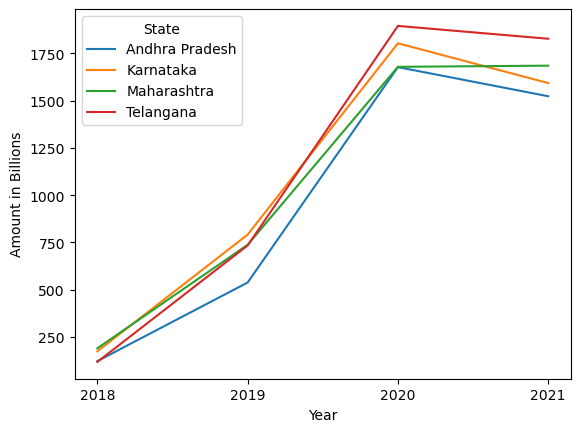

In [13]:
#2.1 Statewise Total txn value and total txn
state_wise_txn_val = State_TxnSplit.pivot_table(index = 'State', columns = 'Year', values = ['Amount'], aggfunc = 'sum')
state_wise_tot_txn = State_TxnSplit.pivot_table(index = 'State', columns = 'Year', values = ['Transactions'], aggfunc = 'sum')
state_wise_txn_val['Grand_Total'] = state_wise_txn_val.sum(axis = 1)
top_5_pivot = state_wise_txn_val.sort_values(by = 'Grand_Total', ascending = False).head(5)
Bottom_5_pivot = state_wise_txn_val.sort_values(by = 'Grand_Total', ascending = False).tail(5)
state_wise_total_amount = (State_TxnSplit.groupby(['State', 'Year'])['Amount'].sum().reset_index())
state_wise = state_wise_total_amount.sort_values(by = ['State', 'Year'], ascending = [True, True])
states = ['Telangana', 'Karnataka', 'Maharashtra', 'Andhra Pradesh']
filtered_4 = state_wise[state_wise['State'].isin(states)].copy()
filtered_4['Amount'] = pd.to_numeric(filtered_4['Amount'])/1000000000
sns.lineplot(x= 'Year', y = 'Amount', data = filtered_4, hue = 'State')
plt.ylabel('Amount in Billions')
plt.xticks(np.arange(2018,2022, step = 1))
plt.show()

In [281]:
#2.2 state wise Quarter wise most use Transaction Type
# •	For each state and quarter, determine most frequent transaction type
state_wise_txn_count = State_TxnSplit.pivot_table(
    index=['State', 'Quarter'], 
    columns='Transaction Type', 
    values='Transactions', 
    aggfunc='sum', 
    fill_value=0)
state_wise_txn_count.head()

Transaction Type                   Financial Services  Merchant payments  \
State                     Quarter                                          
Andaman & Nicobar Islands 1                      1045              59571   
                          2                      1318              93781   
                          3                       664              20560   
                          4                      1054              63732   
Andhra Pradesh            1                    921223          134734657   

Transaction Type                    Others  Peer-to-peer payments  \
State                     Quarter                                   
Andaman & Nicobar Islands 1           1956                 138772   
                          2           2728                 171131   
                          3           1217                  60912   
                          4           2465                 110018   
Andhra Pradesh            1        1396994              255236515   

Transaction Type                   Recharge & bill payments  
State                     Quarter                            
Andaman & Nicobar Islands 1                          121850  
                          2                          180447  
                          3                           84165  
                          4                          106179  
Andhra Pradesh            1                        91440045

In [14]:
# 2.3 Most popular device
# •	Identify device brand with highest registered users per state
popular_device = (State_DeviceData.groupby(['State', 'Brand'])['Registered Users'].sum().reset_index())
top_brand_state = popular_device.sort_values(['State', 'Registered Users'], ascending = [True, False]).groupby('State').head(1)
top_brand_state

,State,Brand,Registered Users
11,Andaman & Nicobar Islands,Xiaomi,97889
22,Andhra Pradesh,Xiaomi,40061549
34,Arunachal Pradesh,Xiaomi,437803
46,Assam,Xiaomi,6979357
60,Bihar,Xiaomi,33721314
73,Chandigarh,Xiaomi,896628
85,Chhattisgarh,Xiaomi,8763373
98,Dadra & Nagar Haveli and Daman & Diu,Xiaomi,638834
109,Delhi,Xiaomi,24114984
120,Goa,Xiaomi,1208672


In [15]:
#2.4 State wise top dist in terms of population
# •	Identify district with highest population per state
# •	Column chart of districts with highest population

dist_population = (District_Demographics.groupby(['State', 'District'])['Population'].sum().reset_index())
state_top_dist_population = dist_population.sort_values(['State', 'Population'], ascending = [True, False]).groupby('State').head(1)
state_top_dist_population['Population'] = pd.to_numeric(state_top_dist_population['Population'], errors = 'coerce')
state_top_dist_population.sort_values('Population', ascending = False).groupby('District').head(10)

,State,District,Population
734,West Bengal,North 24 Parganas,10082852
272,Karnataka,Bangalore Urban,9588910
397,Maharashtra,Pune,9426959
158,Gujarat,Ahmedabad,7208200
554,Tamil Nadu,Chennai,7139882
530,Rajasthan,Jaipur,6663971
633,Uttar Pradesh,Allahabad,5959798
100,Bihar,Patna,5772804
5,Andhra Pradesh,East Godavari,5151549
308,Kerala,Malappuram,4110956


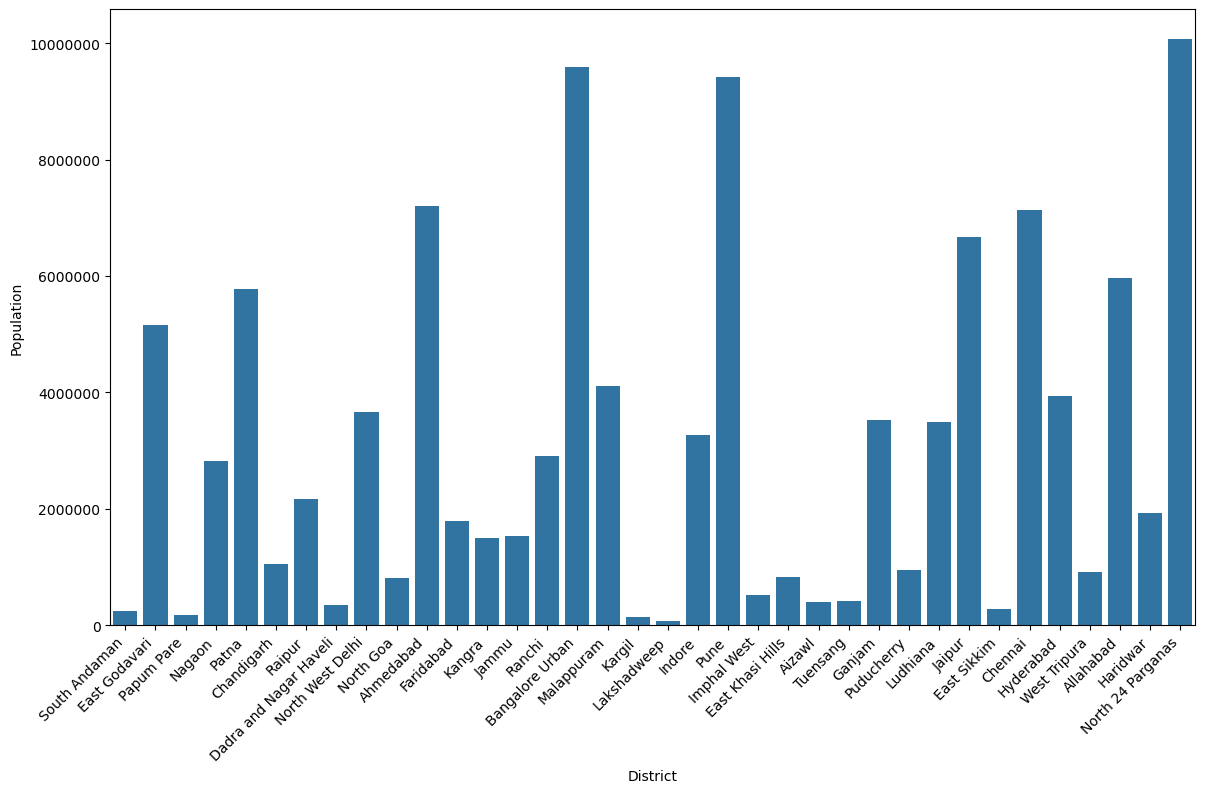

In [16]:
#2.4 bar chart displaying the top Dist Population per state
plt.figure(figsize = (14,8))
sns.barplot(state_top_dist_population,x='District', y='Population')
plt.xticks(rotation = 45, ha = 'right')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [17]:
# 2.5 Average txn value for each state
# •	Compute ATV per state
# •	Top 5 states (highest & lowest ATV)

avg_txn_state = (State_TxnSplit.groupby('State')['ATV'].sum().reset_index())
top_5 = avg_txn_state.sort_values(by = 'ATV', ascending = False).head(5)
bottom_5 = avg_txn_state.sort_values(by = 'ATV', ascending = False).tail(5)
top_5

,State,ATV
0,Andaman & Nicobar Islands,173528.13
17,Ladakh,169010.90
23,Mizoram,139859.66
2,Arunachal Pradesh,138120.95
18,Lakshadweep,134622.51


In [18]:
#2.6 App opens
# •	Total app opens over years and quarters per state
# •	Line plot of app opens over time for selected state

app_opens_state = (State_Txn_Users.groupby(['State','Year','Quarter'])['App Opens'].sum().reset_index())
corr_appopen_txn = State_Txn_Users['App Opens'].corr(State_Txn_Users['Amount'])
#corr_appopen_txn- 0.94

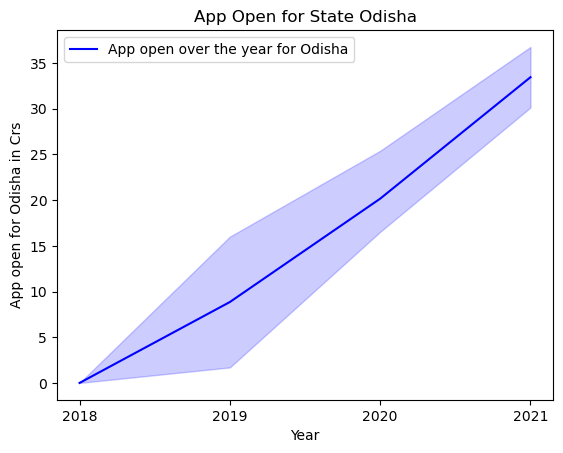

In [19]:
# line plot Trend over years APP open for the state of Odisha
App_open_Odisha = app_opens_state[app_opens_state['State'] == 'Odisha'].copy()
App_open_Odisha['App Opens'] = pd.to_numeric(App_open_Odisha['App Opens'])/10000000
sns.lineplot(data = App_open_Odisha, x = 'Year',y = 'App Opens',  label = 'App open over the year for Odisha', color = 'blue')
plt.xlabel('Year')
plt.ylabel('App open for Odisha in Crs')
plt.title('App Open for State Odisha')
plt.xticks(np.arange(2018,2022, step = 1))
plt.legend()
plt.show()

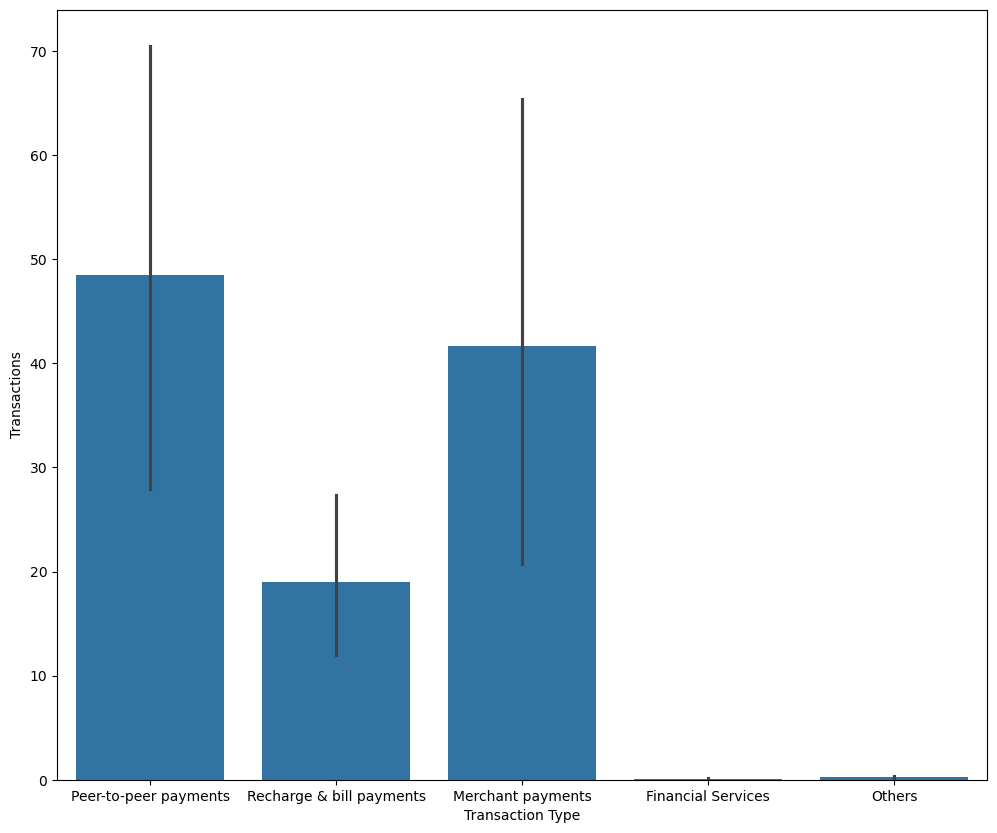

In [20]:
# Recent Year Transaction Type Distribution
recent_year = State_TxnSplit['Year'].max()
Data_recent_year = State_TxnSplit[State_TxnSplit['Year'] == recent_year]
recent_qtr = Data_recent_year['Quarter'].max()
data_recent_qtr = Data_recent_year[Data_recent_year['Quarter'] == recent_qtr].copy()
data_recent_qtr['Transactions'] = pd.to_numeric(data_recent_qtr['Transactions'])/1000000
plt.figure(figsize=(12,10))
sns.barplot(x = 'Transaction Type', y = 'Transactions', data =data_recent_qtr)
plt.ticklabel_format(style='plain', axis='y')
plt.show()

In [21]:
#2.8 unique mapping between District and District code
# •	Identify unique mapping (drop_duplicates)
# •	Export CSV with district name & code

unique_dist =  District_Demographics.drop_duplicates(subset = ['District', 'Code'], keep = 'first')
dist_subset = unique_dist[['District', 'Code']]
dist_subset.to_csv("District_code.csv", index = False)

In [22]:
#Data Quality Check , Difference in aggregation State_wise and Dist_wise
# •	Sum district-level transactions, amount, users → compare with state-level
# •	Display discrepancies
District_Txn_Users
state_wise_total_amount_d = (District_Txn_Users.groupby(['State', 'Year'])['Amount'].sum().reset_index())
dist_total_amount_state = District_Txn_Users.pivot_table(index = 'State', columns = 'Year', values = 'Amount', aggfunc = 'sum')
dist_total_amount_state['State_Total'] = dist_total_amount_state.sum(axis = 1)
difference = dist_total_amount_state['State_Total'] - state_wise_txn_val['Grand_Total']
#Max diff is 2%

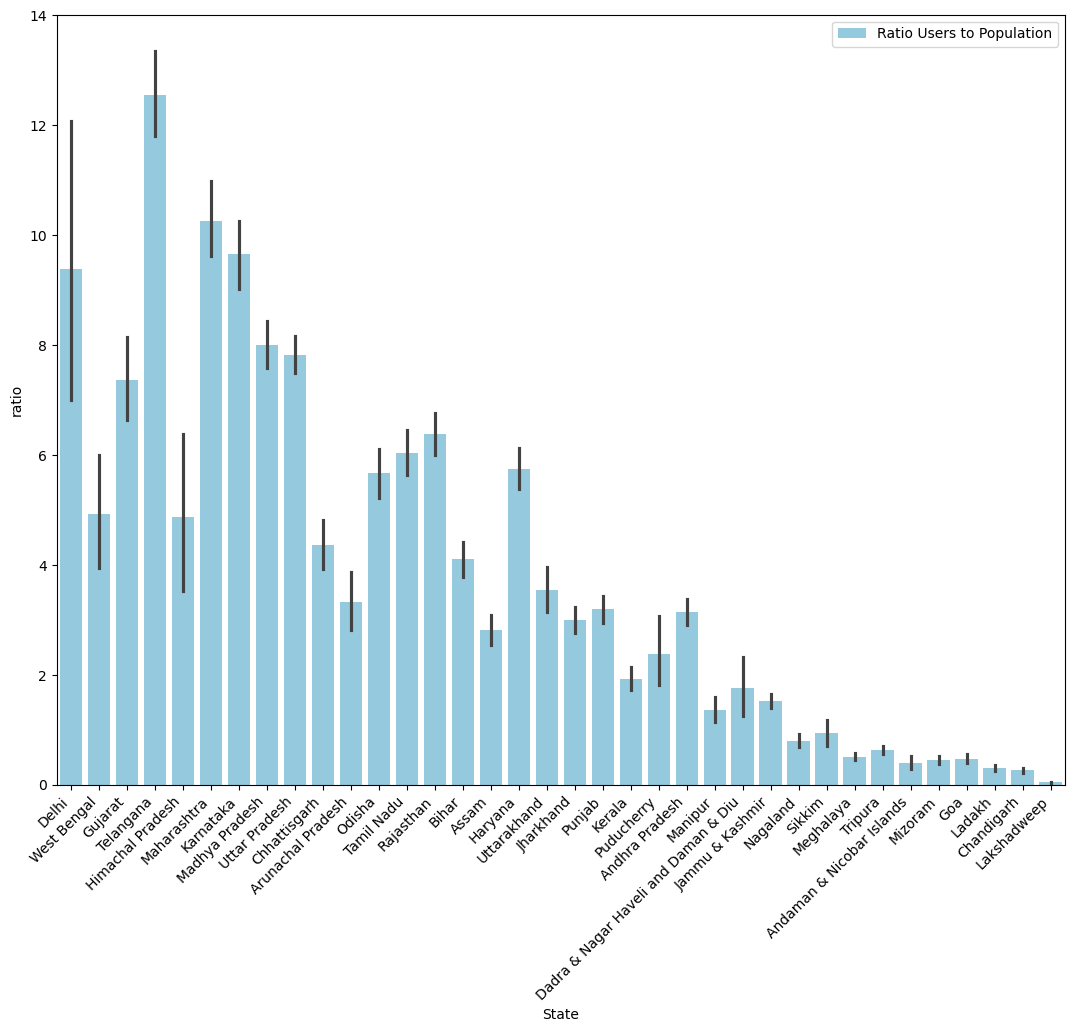

In [23]:
#4.1
# •	Merge State_Txn & Users with District Demographics
# •	Calculate ratio of registered users to population
# •	Column chart

merged_n = pd.merge(State_Txn_Users, District_Demographics, on = 'State', how = 'inner', suffixes = ('_state', '_demog'))
merged_n = merged_n[merged_n['Population'] > 0]
merged_n['ratio'] = merged_n['Registered Users']/merged_n['Population']
merged_n = merged_n.sort_values(by = 'ratio', ascending = False)
plt.figure(figsize = (13,10))
sns.barplot(data = merged_n, x = 'State', y = 'ratio', label = 'Ratio Users to Population', color = 'skyblue')
plt.xticks(rotation = 45, ha = 'right')
plt.show()

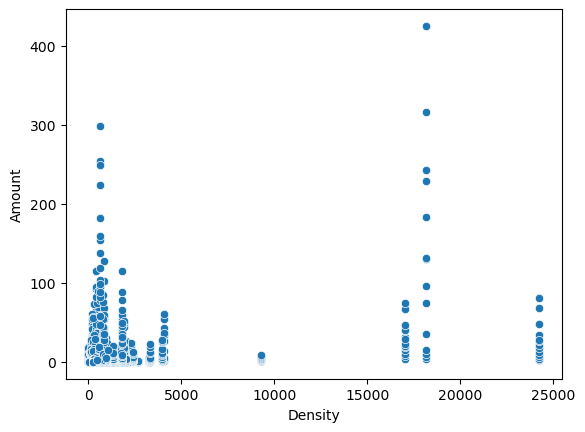

In [24]:
#4.2
# •	Merge District_Txn & Users with District Demographics
# •	Calculate correlation
# •	Scatter plot

merged_dist_demog = pd.merge(District_Txn_Users,District_Demographics, on = ['State', 'District', 'Code'], how = 'inner', suffixes = ('_DD', '_DU')).copy()
merged_dist_demog['Amount'] = pd.to_numeric(merged_dist_demog['Amount'])/1000000000
corr_densit_amount = merged_dist_demog['Amount'].corr(merged_dist_demog['Density'])
# corr_densit_amount-0.33
sns.scatterplot(data = merged_dist_demog, x = 'Density', y = 'Amount')
plt.show()

In [25]:
#4.4
State_Txn_Users
# State_DeviceData

,State,Year,Quarter,Transactions,Amount,ATV,Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,14631761,2197.621091,6740,0
1,Andaman & Nicobar Islands,2018,2,11340,28338535,2498.989022,9405,0
2,Andaman & Nicobar Islands,2018,3,16265,55557471,3415.768284,12149,0
3,Andaman & Nicobar Islands,2018,4,23758,90548336,3811.277720,15222,0
4,Andaman & Nicobar Islands,2019,1,30486,102299740,3355.630147,18596,0
...,...,...,...,...,...,...,...,...
499,West Bengal,2020,2,57676797,100099431877,1735.523418,13222022,198589332
500,West Bengal,2020,3,79954504,156813355855,1961.282329,14448366,246554831
501,West Bengal,2020,4,100340645,199165491365,1984.893473,15662093,291721919
502,West Bengal,2021,1,118254052,242937207475,2054.366877,16808799,316832674


In [26]:
#4.3 Did not merge any 2 Dataframes as the both the data points were available in the same sheet
# •	Merge datasets → calculate average transaction amount per user per state
# •	Top 5 states (highest & lowest)

State_ATV_Users = State_Txn_Users.groupby('State').agg({'Amount':'sum', 'Registered Users': 'sum'})
State_ATV_Users['ratio'] = State_ATV_Users['Amount']/State_ATV_Users['Registered Users']
sorted_ATV_Users = State_ATV_Users.sort_values(by = 'ratio', ascending = False)
top_10 = sorted_ATV_Users.head(10)
bottom_10 = sorted_ATV_Users.tail(10)
top_10

,Amount,Registered Users,ratio
State,,,
Telangana,4574245879730,149224214,30653.509622
Karnataka,4361395878904,203098564,21474.282206
Andhra Pradesh,3187847468845,158007957,20175.233763
Rajasthan,2625584351274,149770064,17530.768707
Delhi,1649942211108,95374654,17299.587908
Manipur,35793251129,2317734,15443.209242
Madhya Pradesh,1915100967826,125339823,15279.269764
Odisha,1220614556981,80404103,15180.998375
Bihar,1639578926744,115284760,14221.991933


In [165]:
#4.4
# •	Merge State_DeviceData with State_Txn & Users
# •	Calculate ratio of users per brand to total users
# •	Bar chart

state_registered_users = (State_Txn_Users.groupby('State')['Registered Users'].sum().reset_index())
state_device_users = (State_DeviceData.groupby(['State', 'Brand'])['Registered Users'].sum().reset_index())
devices = (state_device_users.groupby('State')['Registered Users'].sum().reset_index()) #used for validation of the registered user match
Merged_df = pd.merge(state_registered_users,state_device_users, on = 'State', how = 'inner', suffixes = ('_SU', '_DU'))
Merged_df['ratio'] = (Merged_df['Registered Users_DU'] / Merged_df['Registered Users_SU'])
Merged_df

,State,Registered Users_SU,Brand,Registered Users_DU,ratio
0,Andaman & Nicobar Islands,408396,Apple,9334,0.022855
1,Andaman & Nicobar Islands,408396,Huawei,11497,0.028152
2,Andaman & Nicobar Islands,408396,Lenovo,5362,0.013129
3,Andaman & Nicobar Islands,408396,Motorola,9491,0.023240
4,Andaman & Nicobar Islands,408396,OnePlus,15397,0.037701
...,...,...,...,...,...
443,West Bengal,144242183,Others,17526532,0.121508
444,West Bengal,144242183,Realme,9322038,0.064628
445,West Bengal,144242183,Samsung,30516315,0.211563
446,West Bengal,144242183,Vivo,18755122,0.130025


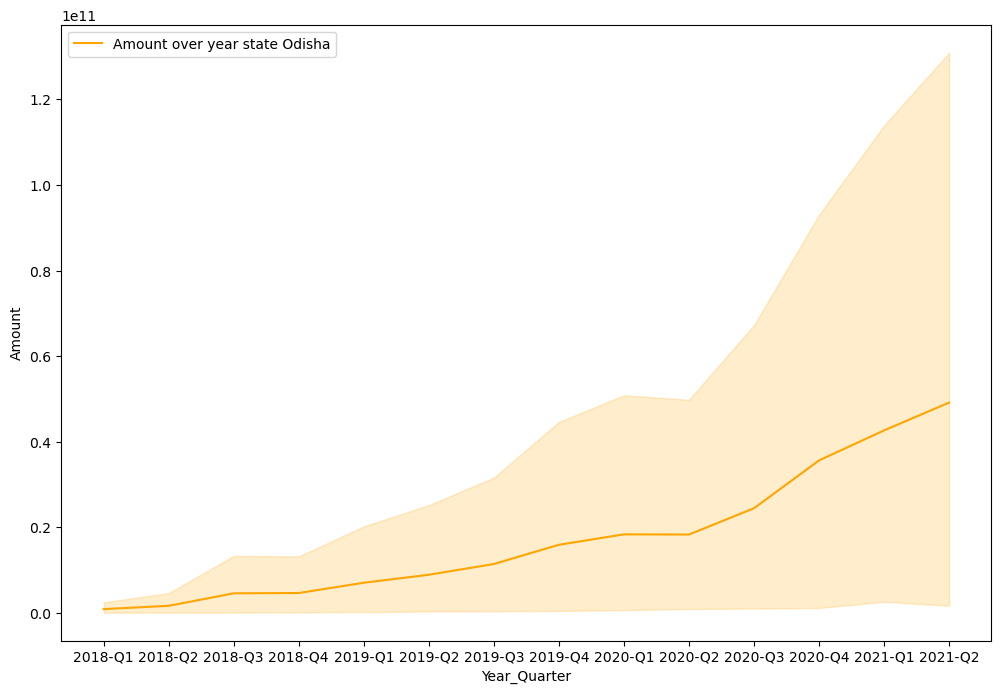

In [12]:
#5.1
# 1.	Create a line plot showing the total number of transactions and the total transaction amount over time (years and quarters) for a selected state.
# [Hint: you can select any state, maybe your home state or state with max transactions]

State_TxnSplit_OD = State_TxnSplit[State_TxnSplit['State']=='Odisha'].copy()
State_Txn_Users = State_Txn_Users.sort_values(['Year','Quarter'])
State_TxnSplit_OD['Year_Quarter'] = State_TxnSplit_OD['Year'].astype(str) + '-Q' + State_TxnSplit_OD['Quarter'].astype(str)
plt.figure(figsize = (12,8))
sns.lineplot(data = State_TxnSplit_OD,x = 'Year_Quarter', y = 'Amount', color = 'Orange', label = 'Amount over year state Odisha')
# plt.plot(State_TxnSplit_OD['Year_Quarter'], State_TxnSplit_OD['Transactions'], color = 'blue', label = 'Transactions over year')
plt.show()


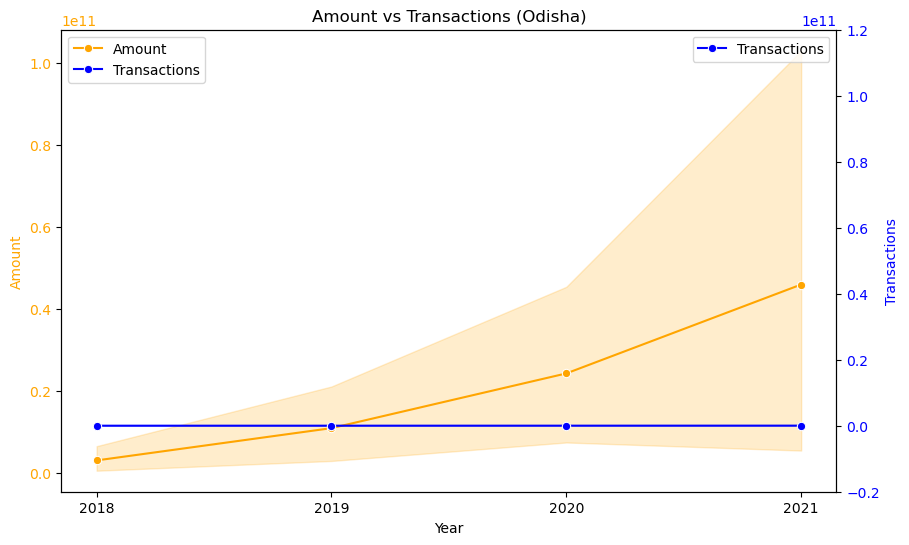

In [13]:
# Create figure and first axis
fig, ax1 = plt.subplots(figsize=(10,6))

# Line for Amount (left y-axis)
sns.lineplot(data=State_TxnSplit_OD, 
             x='Year', y='Amount', 
             color='orange', marker='o', 
             label='Amount', ax=ax1)

ax1.set_ylabel("Amount", color='orange')
ax1.tick_params(axis='y', labelcolor='orange')
plt.xticks(np.arange(2018,2022, step = 1))

# Create second y-axis for Transactions
ax2 = ax1.twinx()

sns.lineplot(data=State_TxnSplit_OD, 
             x='Year', y='Transactions', 
             color='blue', marker='o', 
             label='Transactions', ax=ax2)

ax2.set_ylabel("Transactions", color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

ax2.set_ylim(ax1.get_ylim())
ax2.set_yticks(ax1.get_yticks())

# Title and formatting
plt.title("Amount vs Transactions (Odisha)")
plt.xticks(rotation=45)

# Add legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.show()


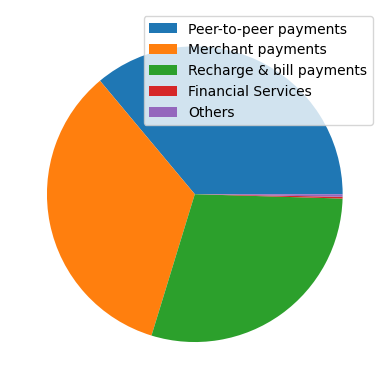

,State,Year,Quarter,Transaction Type,Transactions,Amount,ATV,pct
1185,Kerala,2021,2,Peer-to-peer payments,17026648,58152644526,3415.39,36.08
1186,Kerala,2021,2,Merchant payments,16135060,11263178335,698.06,34.19
1187,Kerala,2021,2,Recharge & bill payments,13809151,4645548909,336.41,29.26
1188,Kerala,2021,2,Financial Services,88830,88370679,994.83,0.19
1189,Kerala,2021,2,Others,131344,77063984,586.73,0.28


In [45]:
State_TxnSplit_Kerala = State_TxnSplit[(State_TxnSplit['State'] == 'Kerala') & (State_TxnSplit['Year']==2021) & (State_TxnSplit['Quarter']==2)].copy()

State_TxnSplit_Kerala['pct'] = round(State_TxnSplit_Kerala['Transactions']*100 / State_TxnSplit_Kerala['Transactions'].sum(),2)
State_TxnSplit_Kerala
plt.pie(State_TxnSplit_Kerala['pct'])
plt.legend(labels = State_TxnSplit_Kerala['Transaction Type'], loc = 'best')
plt.show()


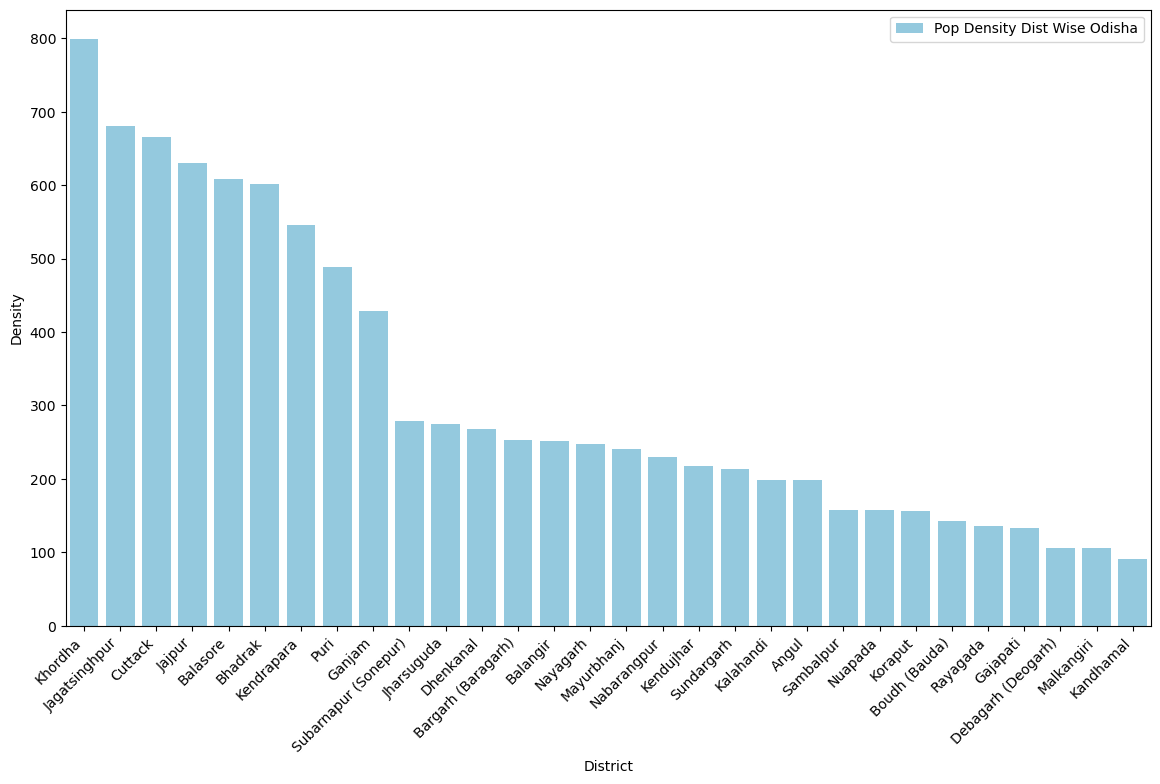

In [70]:
District_Demographics_Od = District_Demographics[District_Demographics['State'] == 'Odisha'].copy()
District_Demographics_Od = District_Demographics_Od.sort_values(by = 'Density', ascending = False)
plt.figure(figsize = (14,8))
sns.barplot(District_Demographics_Od, x = 'District', y = 'Density', color = 'skyblue',label = 'Pop Density Dist Wise Odisha')
plt.xticks(rotation = 45, ha = 'right')
plt.legend()
plt.show()

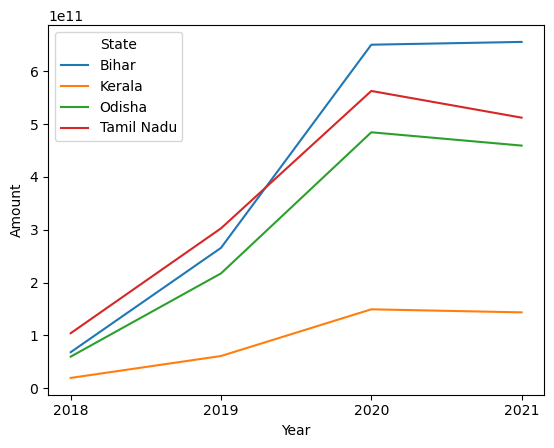

In [27]:
# Plot to find the trend of transaction amount over the year for different states
State_TxnSplit.head(10)
# state_wise_txn_val = State_TxnSplit.groupby(['State', 'Year'])['Transactions'].sum()
# state_wise_txn_val
state_wise_txn_val = State_TxnSplit.pivot_table(index = 'State', columns = 'Year', values = ['Amount'], aggfunc = 'sum')
state_wise_tot_txn = State_TxnSplit.pivot_table(index = 'State', columns = 'Year', values = ['Transactions'], aggfunc = 'sum')
state_wise_txn_val['Grand_Total'] = state_wise_txn_val.sum(axis = 1)
top_5_pivot = state_wise_txn_val.sort_values(by = 'Grand_Total', ascending = False).head(5)
Bottom_5_pivot = state_wise_txn_val.sort_values(by = 'Grand_Total', ascending = False).tail(5)
state_wise_total_amount = (State_TxnSplit.groupby(['State', 'Year'])['Amount'].sum().reset_index())
state_wise = state_wise_total_amount.sort_values(by = ['State', 'Year'], ascending = [True, True])
filtered_4 = state_wise[state_wise['State'].isin(['Odisha', 'Kerala', 'Tamil Nadu', 'Bihar'])]
filtered_4
sns.lineplot(x= 'Year', y = 'Amount', data = filtered_4, hue = 'State')
plt.xticks(np.arange(2018,2022, step = 1))
plt.show()

- Analyzed year‑on‑year transaction volumes across states, revealing an overall consistent upward trend.
- Observed a significant surge in transactions from 2018 to 2019, with an average 249% YoY growth across four states, reflecting rapid adoption of digital payments.
- Noted continued expansion in 2020, though at a moderated pace, with an average 124% YoY growth, indicating sustained but stabilizing digital payment usage during the COVID‑19 period.
- Observed that while preliminary 2021 data shows a decline, the full trend for 2021 could not be established due to incomplete dataset availability.
- Confirmed that almost all states exhibited growth trajectories, highlighting the nationwide shift toward digital payment ecosystems.

In [308]:
new_dist_demog = District_Demographics.groupby('State').agg({'Population': 'sum', 'Density':'sum'})
merged_state_demog = pd.merge(State_TxnSplit,new_dist_demog, on = 'State', how = 'inner')
correlation_pop_Amount = merged_state_demog['Amount'].corr(merged_state_demog['Population'])
#correlation_pop_Amount 0.20383580220643852
correlation_density_Amount = merged_state_demog['Amount'].corr(merged_state_demog['Density'])
# correlation_density_Amount-0.12554023109685727
correlation_density_txn = merged_state_demog['Transactions'].corr(merged_state_demog['Density'])
# correlation_density_txn-0.18808266502801563
correlation_population_txn = merged_state_demog['Transactions'].corr(merged_state_demog['Population'])
# correlation_population_txn-0.2926165111054365

np.float64(0.2926165111054365)

- Population vs Amount → 0.20
Weak positive correlation: states with larger populations tend to have slightly higher transaction amounts.
- Density vs Amount → 0.13
Very weak positive correlation: population density shows only a minimal relationship with transaction amounts.
- Density vs Transactions → 0.19
Weak positive correlation: denser states show a small tendency toward higher transaction counts.
- Population vs Transactions → 0.29
Moderate positive correlation: states with larger populations are somewhat more likely to have higher transaction volumes.
Correlation analysis revealed weak to moderate positive relationships between demographics and transaction metrics, indicating that while population and density contribute, they are not the dominant factors driving digital payment adoption.


Key Insights:
Performed EDA on 5 multi-sheet PhonePe datasets (state & district level), cleaning and transforming those records to uncover
transaction trends, device preferences, and demographic correlations; reduced data quality gaps to <2% between state and
district aggregations.
• Identified Xiaomi as the leading device brand in 95% of states (Samsung leading only in Sikkim), and highlighted Odisha’s 30%+
growth in app engagement over 4 years through time-series visualizations.
• Conducted correlation analysis between demographics and digital payments, revealing weak-to-moderate positive
relationships (Population vs Transactions: 0.29, Density vs Transactions: 0.19), demonstrating that population size
contributes but is not the dominant driver of adoption.
• Identified correlation of App opens to Total Amount is strongly positive correlation.

Marketing Strategies: 
1) Partnership with Xiaomi for a targeted marketing campaign for individuals using Xiami device but doesnot have Phonepe(Easy Target Segment)
2) Budget allocation to high potential  areas
3) Focusing on strategies where we can push for APP open can directly result in higher transaction.